In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("diabetes_dirty_dataset.csv")
df

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,NaN,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,NaN,3.0,0
1011,P0746,2,131,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   str    
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    str    
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome            

In [4]:
df["Glucose"]=df["Glucose"].str.strip("!@#$%^&*({}[];',//loO?)")


In [5]:
df["Glucose"]=df["Glucose"].astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   str    
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    float64
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome            

In [6]:
df["Outcome"].unique()

<StringArray>
['0', '1', 'Yes', '1.0', '0.0', 'No', 'TRUE', 'FALSE']
Length: 8, dtype: str

In [7]:
df["Outcome"]=df["Outcome"].replace({"0":0.0,"1":1.0,"Yes":1.0,"No":0.0,"True":1.0,"False":0.0,"TRUE":1.0,"FALSE":0.0})


In [8]:
df["Outcome"]=df["Outcome"].astype(float)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   str    
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    float64
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome            

In [10]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
count,1015.000000,935.000000,1015.000000,935.000000,937.000000,1015.000000,1015.000000,1015.000000,1015.000000,1015.000000,1015.000000,934.000000,933.000000,1015.000000
mean,3.953695,125.014973,77.821675,28.067380,247.248666,32.257143,0.886528,41.093005,200.347783,139.683547,78.359606,35.294540,5.025938,0.353695
std,3.021753,51.731246,25.586700,12.381894,965.699749,11.635791,0.565512,19.757258,29.370453,2.948790,19.932078,14.188464,2.924371,0.478352
min,-7.000000,-5.000000,0.000000,-43.000000,-10.000000,-3.000000,0.080000,-1.000000,150.000000,135.000000,-99.000000,10.100000,0.000000,0.000000
25%,2.000000,94.500000,65.000000,20.000000,85.000000,25.450000,0.441000,29.000000,176.000000,137.100000,69.000000,23.225000,2.500000,0.000000
50%,3.000000,122.000000,76.000000,28.000000,136.000000,31.100000,0.793000,38.000000,202.000000,139.400000,80.000000,35.300000,5.100000,0.000000
75%,6.000000,144.000000,87.000000,37.000000,196.000000,36.850000,1.146000,51.000000,226.000000,142.200000,90.000000,47.850000,7.700000,1.000000
max,12.000000,600.000000,300.000000,54.000000,9999.000000,120.500000,2.413000,200.000000,250.000000,145.000000,100.000000,59.800000,10.000000,1.000000


In [11]:
df.isnull().sum()


PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64

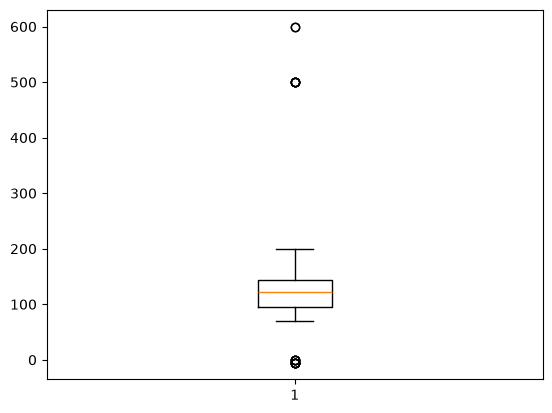

In [12]:
plt.boxplot(df["Glucose"].dropna())
q1=df["Glucose"].quantile(0.25)
q3=df["Glucose"].quantile(0.75)
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
df=df[(df["Glucose"]<=ub) & (df["Glucose"]>=lb)]

{'whiskers': [<matplotlib.lines.Line2D at 0x115d54d70>,
 'caps': [<matplotlib.lines.Line2D at 0x115d55010>,
 'boxes': [<matplotlib.lines.Line2D at 0x115d54c20>],
 'medians': [<matplotlib.lines.Line2D at 0x115d552b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x115d55400>],
 'means': []}

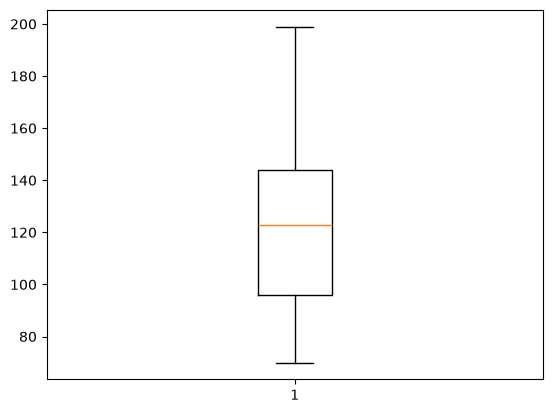

In [13]:
plt.boxplot(df["Glucose"])

In [14]:
df["Glucose"]=df["Glucose"].fillna(df["Glucose"].median())

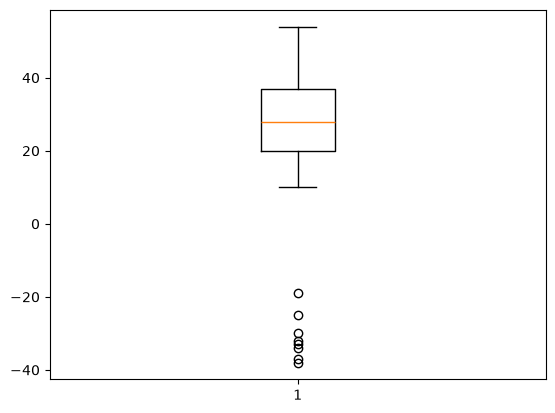

In [15]:
plt.boxplot(df["SkinThickness"].dropna())
df=df[df["SkinThickness"]>0]


{'whiskers': [<matplotlib.lines.Line2D at 0x115de38c0>,
 'caps': [<matplotlib.lines.Line2D at 0x115de3b60>,
 'boxes': [<matplotlib.lines.Line2D at 0x115de3770>],
 'medians': [<matplotlib.lines.Line2D at 0x115de3e00>],
 'fliers': [<matplotlib.lines.Line2D at 0x115e54050>],
 'means': []}

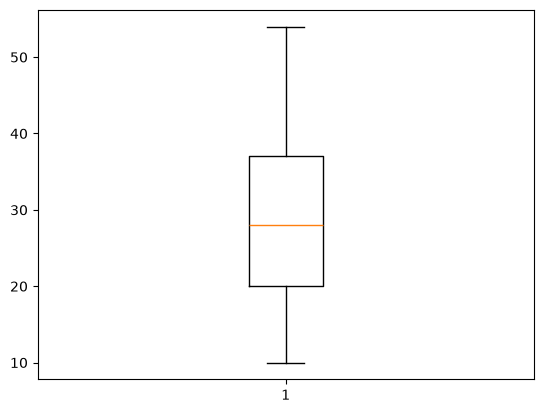

In [16]:
plt.boxplot(df["SkinThickness"])

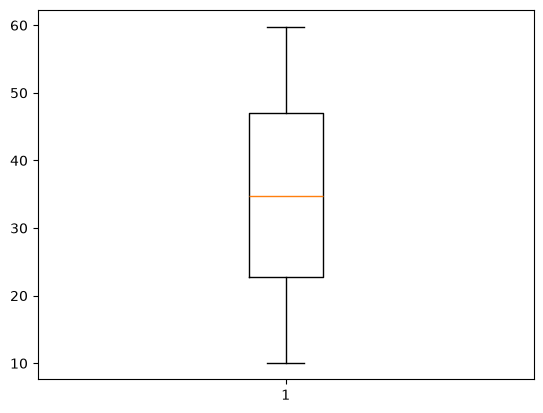

In [17]:
plt.boxplot(df["VitaminD"].dropna())
df["VitaminD"]=df["VitaminD"].fillna(df["VitaminD"].median())

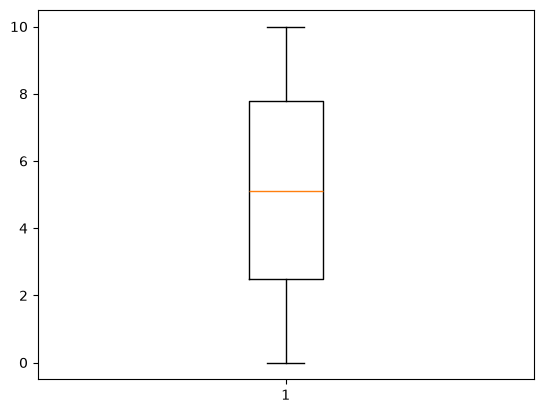

In [18]:
plt.boxplot(df["ExerciseHrsPerWeek"].dropna())
df["ExerciseHrsPerWeek"]=df["ExerciseHrsPerWeek"].fillna(df["ExerciseHrsPerWeek"].median())

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 833 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 833 non-null    str    
 1   Pregnancies               833 non-null    int64  
 2   Glucose                   833 non-null    float64
 3   BloodPressure             833 non-null    int64  
 4   SkinThickness             833 non-null    float64
 5   Insulin                   770 non-null    float64
 6   BMI                       833 non-null    float64
 7   DiabetesPedigreeFunction  833 non-null    float64
 8   Age                       833 non-null    float64
 9   Cholesterol               833 non-null    int64  
 10  SodiumLevel               833 non-null    float64
 11  HeartRate                 833 non-null    int64  
 12  VitaminD                  833 non-null    float64
 13  ExerciseHrsPerWeek        833 non-null    float64
 14  Outcome                  

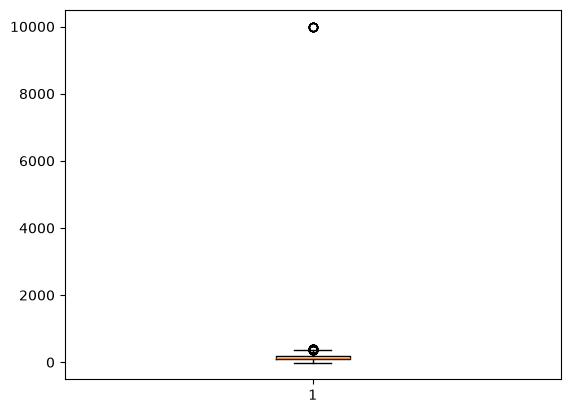

In [20]:
plt.boxplot(df["Insulin"].dropna())
q1=df["Insulin"].quantile(0.25)
q3=df["Insulin"].quantile(0.75)
iqr=q3-q1
iqr=q3-q1
lb=q1-1.5*iqr
ub=q3+1.5*iqr
df=df[(df["Insulin"]<ub) & (df["Insulin"]>lb)]

{'whiskers': [<matplotlib.lines.Line2D at 0x115fbcad0>,
 'caps': [<matplotlib.lines.Line2D at 0x115fbcd70>,
 'boxes': [<matplotlib.lines.Line2D at 0x115fbc980>],
 'medians': [<matplotlib.lines.Line2D at 0x115fbd010>],
 'fliers': [<matplotlib.lines.Line2D at 0x115fbd160>],
 'means': []}

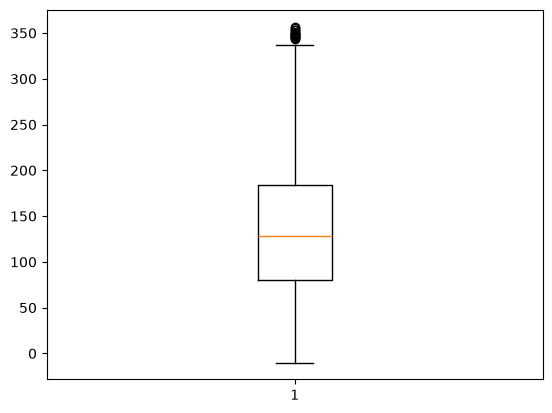

In [21]:
#plx.scatter(df["VitaminD"],df["BloodPressure"])
plt.boxplot(df["Insulin"].dropna())

In [22]:
df
X=df.drop(columns=["PatientID","Outcome"])
X
y=df["Outcome"]
X.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Cholesterol                 0
SodiumLevel                 0
HeartRate                   0
VitaminD                    0
ExerciseHrsPerWeek          0
dtype: int64

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
model=LogisticRegression()
scaler=StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [24]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [25]:
model.predict([x_train[0]])

array([0.])

In [26]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,classification_report)
y_pred=model.predict(x_test)
print("the mae is",mean_absolute_error(y_test,y_pred))
print("the mse is ",mean_squared_error(y_test,y_pred))
print("r2 score is ",r2_score(y_test,y_pred))

the mae is 0.041379310344827586
the mse is  0.041379310344827586
r2 score is  0.8131443298969072


In [27]:
from sklearn.metrics import (confusion_matrix,accuracy_score)
confusion_matrix(y_test,y_pred)

array([[96,  1],
       [ 5, 43]])

In [28]:
accuracy_score(y_test,y_pred)

0.9586206896551724

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97        97
         1.0       0.98      0.90      0.93        48

    accuracy                           0.96       145
   macro avg       0.96      0.94      0.95       145
weighted avg       0.96      0.96      0.96       145



In [30]:
np.round(model.predict_proba(x_test),3)

array([[0.998, 0.002],
       [0.999, 0.001],
       [0.999, 0.001],
       [0.713, 0.287],
       [0.989, 0.011],
       [0.988, 0.012],
       [0.041, 0.959],
       [0.998, 0.002],
       [1.   , 0.   ],
       [0.38 , 0.62 ],
       [0.998, 0.002],
       [0.003, 0.997],
       [0.003, 0.997],
       [0.999, 0.001],
       [0.957, 0.043],
       [0.003, 0.997],
       [0.001, 0.999],
       [0.998, 0.002],
       [0.   , 1.   ],
       [0.995, 0.005],
       [0.96 , 0.04 ],
       [0.964, 0.036],
       [0.004, 0.996],
       [0.997, 0.003],
       [0.999, 0.001],
       [0.908, 0.092],
       [1.   , 0.   ],
       [0.975, 0.025],
       [0.033, 0.967],
       [0.623, 0.377],
       [0.997, 0.003],
       [0.001, 0.999],
       [0.002, 0.998],
       [0.003, 0.997],
       [0.996, 0.004],
       [0.996, 0.004],
       [0.718, 0.282],
       [0.997, 0.003],
       [0.937, 0.063],
       [0.995, 0.005],
       [0.826, 0.174],
       [0.989, 0.011],
       [0.114, 0.886],
       [0.9

/var/folders/c6/nt0k_yy91x16phw4mhjl9_hh0000gn/T/ipykernel_11480/1371114212.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


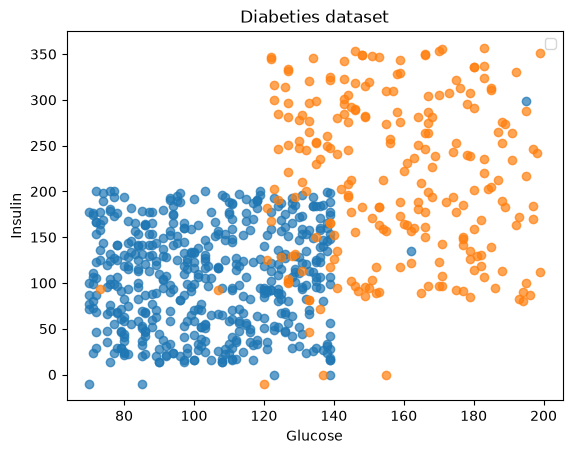

In [36]:
for target_value,label in [(0,"no"),(1,"yes")]:
    subset=X[y==target_value]

    plt.scatter(
        subset["Glucose"],
        subset["Insulin"],
        alpha=0.7
    )
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Diabeties dataset")
plt.legend()

In [43]:
df[df.corr(numeric_only=True)>0.09].columns


Index(['PatientID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cholesterol',
       'SodiumLevel', 'HeartRate', 'VitaminD', 'ExerciseHrsPerWeek',
       'Outcome'],
      dtype='str')

<Axes: >

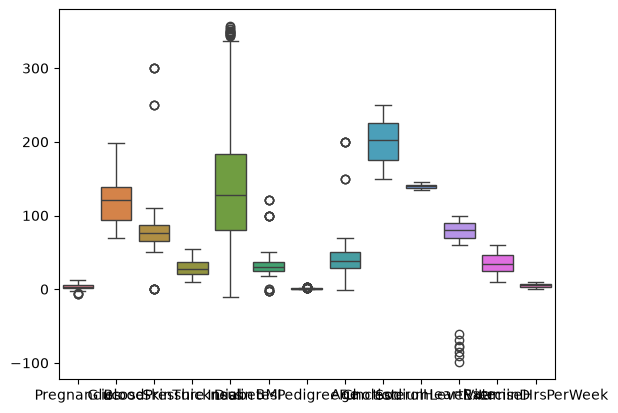

In [45]:
sns.boxplot(df[[ 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cholesterol',
       'SodiumLevel', 'HeartRate', 'VitaminD', 'ExerciseHrsPerWeek']])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Training data: (579, 13)
Testing data : (145, 13)


In [47]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [49]:
from sklearn.svm import SVC
svm_linear=SVC(
    kernel="linear",
    C=1
)
svm_linear.fit(X_train_scaled, y_train)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [50]:
svm_poly = SVC(
    kernel='poly',
    degree=3,
    C=1,
    gamma='scale'
)

svm_poly.fit(X_train_scaled, y_train)

print("Polynomial SVM trained successfully.")

Polynomial SVM trained successfully.


In [51]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train_scaled, y_train)

print("RBF SVM trained successfully.")

RBF SVM trained successfully.


In [52]:
print("Number of support vectors – Linear SVM:",
      len(svm_linear.support_))

print("Number of support vectors – Polynomial SVM:",
      len(svm_poly.support_))

print("Number of support vectors – RBF SVM:",
      len(svm_rbf.support_))


Number of support vectors – Linear SVM: 68
Number of support vectors – Polynomial SVM: 183
Number of support vectors – RBF SVM: 141


In [54]:
X_vis = X[['Glucose', 'Insulin']]

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vis_scaler = StandardScaler()

X_vis_train_scaled = vis_scaler.fit_transform(X_vis_train)
X_vis_test_scaled = vis_scaler.transform(X_vis_test)

In [55]:
vis_linear = SVC(kernel='linear', C=1)
vis_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale')
vis_rbf = SVC(kernel='rbf', C=1, gamma='scale')

vis_linear.fit(X_vis_train_scaled, y_vis_train)
vis_poly.fit(X_vis_train_scaled, y_vis_train)
vis_rbf.fit(X_vis_train_scaled, y_vis_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
def plot_decision_boundary(model, X, y, title):
    X_array = np.asarray(X)
    y_array = np.asarray(y)

    x_min, x_max = X_array[:, 0].min() - 1, X_array[:, 0].max() + 1
    y_min, y_max = X_array[:, 1].min() - 1, X_array[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7,5))

    plt.contourf(
        xx, yy, Z,
        alpha=0.20
    )

    plt.scatter(
        X_array[:, 0],
        X_array[:, 1],
        c=y_array,
        edgecolors='k',
        s=45
    )

    # Highlight support vectors
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_

        plt.scatter(
            sv[:, 0],
            sv[:, 1],
            facecolors='none',
            edgecolors='black',
            s=120,
            linewidths=1.5,
            label='Support Vectors'
        )

        plt.legend()

    plt.xlabel("Standardized Mean Radius")
    plt.ylabel("Standardized Mean Texture")
    plt.title(title)
    plt.show()

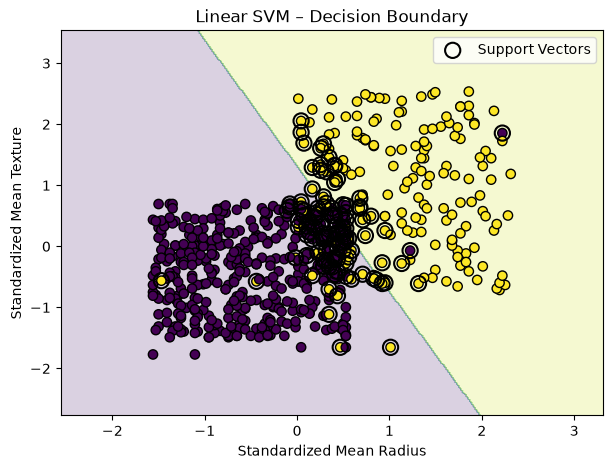

In [59]:
plot_decision_boundary(
    vis_linear,
    X_vis_train_scaled,
    y_vis_train,
    "Linear SVM – Decision Boundary"
)

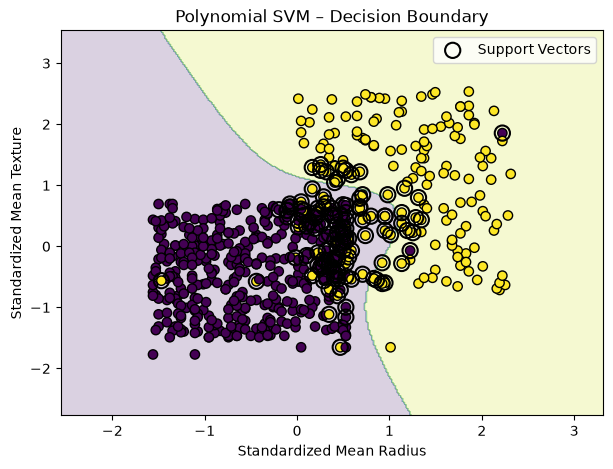

In [60]:
plot_decision_boundary(
    vis_poly,
    X_vis_train_scaled,
    y_vis_train,
    "Polynomial SVM – Decision Boundary"
)

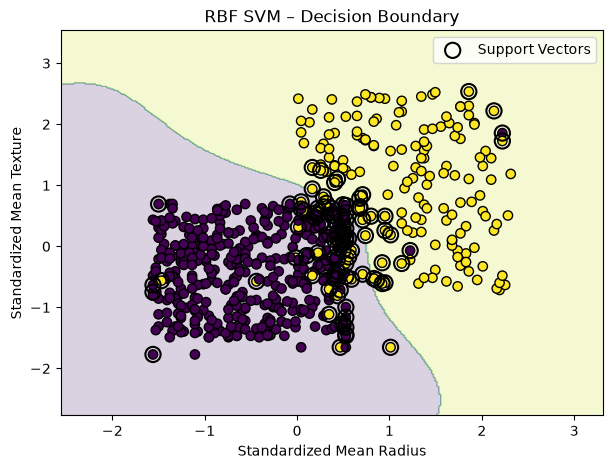

In [61]:
plot_decision_boundary(
    vis_rbf,
    X_vis_train_scaled,
    y_vis_train,
    "RBF SVM – Decision Boundary"
)


In [62]:
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Predictions generated successfully.")


Predictions generated successfully.


In [64]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate_model("Linear SVM", y_test, y_pred_linear),
    evaluate_model("Polynomial SVM", y_test, y_pred_poly),
    evaluate_model("RBF SVM", y_test, y_pred_rbf)
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.965517,1.0,0.893617,0.943820
1,Polynomial SVM,0.931034,1.0,0.787234,0.880952
2,RBF SVM,0.979310,1.0,0.936170,0.967033


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


In [67]:
svm_pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('svm',SVC())]
)
param_grid={
    'svm__kernel':['linear',"poly","rbf"],
    'svm__C':[0.1,1,10,100],
    'svm__degree':[2,3,4],
    'svm__gamma':['scale',"auto",0.01,0.1,1]
}
grid_search =GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__degree': [2, 3, ...], 'svm__gamma': ['scale', 'auto', ...], 'svm__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added

In [68]:

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'svm__C': 1, 'svm__degree': 2, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best Cross-Validation Score:
0.9637931034482758
